# **NeuroScan: Brain Tumor MRI Classification with Controlled Leakage Analysis**

### CS 475/675 Final Project Report

NeuroScan is a two-stage deep learning pipeline that classifies brain MRI scans into eight tumor categories, with conditional glioma subtyping when the primary model predicts glioma. I also ran a controlled experiment to measure how much patient-level data leakage inflates test accuracy on popular brain tumor MRI benchmarks. The short answer: up to 11.6 percentage points on specific classes.

# Project Name: NeuroScan
Project mentor: N/A

Solo Project, kshay3@jh.edu, Kiran Shay

Link to git repo: [github.com/kiranshay/brain-tumor-classifier](https://github.com/kiranshay/brain-tumor-classifier)

Live demo: [kiranshay.github.io/brain-tumor-classifier](https://kiranshay.github.io/brain-tumor-classifier)

# Outline and Deliverables

### Completed Deliverables

**Must accomplish:**

1. **8-class Stage 1 classifier trained and evaluated.** EfficientNet-B0 on the combined dataset, reporting per-class precision/recall/F1, confusion matrix, and Wilson 95% confidence intervals. Covered in [Results](#results) and [Experimental Setup](#experimental-setup).

2. **Clean dataset with patient-aware splits.** Built via `build_clean_dataset.py` using inferred patient IDs and `GroupShuffleSplit` on data44, with preserved published splits on data1/data2. Quantified leakage inflation at +2.52 pp overall, +11.6 pp on d1 glioma. Covered in [Pre-processing](#pre-processing) and [Results](#results).

3. **Wilson 95% confidence intervals for all per-class metrics.** Computed via `wilson_intervals.py`, revealing that rare-class point estimates (e.g., papilloma recall 0.657) carry 30-percentage-point intervals at n=35. Covered in [Results](#results).

**Expected to accomplish:**

4. **Stage 2 glioma subtype classifier.** 4-class EfficientNet-B0 (astrocytoma, ependymoma, glioblastoma, oligodendroglioma) integrated into a conditional cascade where Stage 2 fires only when Stage 1 predicts glioma. Covered in [Methods](#methods).

5. **Grad-CAM interpretability.** Implemented via hooks on the final convolutional block, generating heatmaps overlaid on input MRIs. Available on-demand through the deployed web app. Covered in [Methods](#methods).

6. **Source confound analysis.** Analyzed whether data44-only rare classes achieve high accuracy via scanner signature recognition rather than tumor morphology. Covered in [Results](#results).

**Would like to accomplish:**

7. **Full-stack web deployment.** FastAPI backend on Render, vanilla JS frontend on GitHub Pages, Supabase Postgres for prediction history and statistics. Live at the demo link above. Covered in [Methods](#methods).

### Uncompleted Deliverables

8. **Class-weighted loss / weighted random sampling.** Not implemented. The clean training pipeline (`train_clean.py`) uses unweighted `CrossEntropyLoss`. Addressing class imbalance remains future work; the Wilson confidence intervals partially compensate by quantifying the resulting uncertainty on rare classes.

9. **Standalone contamination research contribution.** The controlled leakage experiment is complete and documented, but was not developed into a separate paper submission. The per-source analysis showing that leakage selectively inflates the classes with real distributional problems is the key finding that would anchor such a contribution.

# Preliminaries

## What problem were you trying to solve or understand?

The goal is to classify brain tumor types from MRI scans automatically. This is a multi-class image classification problem, similar to what we did in lecture with CIFAR-10 and ImageNet, but medical imaging adds a few complications: the classes are imbalanced, images come from different MRI sequences (T1, T2, T1C+), and there's a serious risk of data leakage when patients contribute multiple slices to the dataset.

That last point turned out to be the most interesting part of the project. Most published results on these Kaggle brain tumor datasets use image-level random splits for train/test. If a patient has 10 MRI slices and you randomly shuffle them, some end up in train and some in test. The model memorizes patient-specific features and test accuracy looks great, but it doesn't reflect real generalization. Almost every Kaggle notebook I found on these datasets does this. I wanted to actually measure how bad the problem is, so I set up a controlled experiment where the only thing that changes between two training runs is the split strategy (patient-aware vs. random image-level). More on that in the results section.

On the ethics side: if someone deployed a model in a clinical screening context and cited 99% accuracy from a leaked evaluation, that would give false confidence. We measured a +11.6 pp recall inflation on glioma from the d1 dataset alone. A doctor looking at the leaked number would see 98% recall and move on; the honest number is 86.3%. That's a real gap when the question is whether to order a biopsy. And for rare classes like papilloma, the Wilson confidence interval spans [0.49, 0.79] at n=35. We genuinely don't know if the model catches half or three-quarters of papillomas.

## Datasets

I combined three publicly available Kaggle datasets, totaling over 15,000 MRI images:

| Source | Kaggle Slug | Classes | Images | Split Provided? |
|--------|------------|---------|--------|-----------------|
| **Brain Tumor MRI (data1)** | `masoudnickparvar/brain-tumor-mri-dataset` | 4 (glioma, meningioma, no tumor, pituitary) | ~7,023 | Yes (Training/Testing folders) |
| **BRISC 2025 (data2)** | `briscdataset/brisc2025` | 4 (same as above) | ~6,000 | Yes (train/test folders) |
| **Brain Tumor 44-class (data44)** | `fernando2rad/brain-tumor-mri-images-44c` | 44 fine-grained types across T1, T2, T1C+ sequences | ~2,500+ | No |

**Data1** is the most commonly used brain tumor MRI benchmark on Kaggle. It has clean 4-class labels with a pre-defined train/test split, but it likely contains multiple slices per patient (I found near-duplicate images across splits).

**Data2 (BRISC)** adds axial, sagittal, and coronal orientations for the same 4 classes. The multi-orientation nature means it almost certainly has patient-level overlap within its published split too.

**Data44** has fine-grained tumor types organized as `<TumorName> <Sequence>` folders (e.g., "Astrocitoma T1", "Meningioma T1C+"). This is the only source for the four rare classes (schwannoma, neurocytoma, carcinoma, papilloma) and all the glioma subtype labels. It has no pre-defined split, so I had to construct one.

The 8-class Stage 1 model trains on all three datasets combined. The trustworthy 4-class model and the leaky control use only data1 + data2 (to keep the leakage experiment clean). The glioma subtype model uses data44 only.

In [1]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display, Image, Markdown

RESULTS = Path("results")

# Load run summaries for all three experiments
for run_name in ["trustworthy_4class", "extended_8class", "leaky_4class"]:
    summary_path = RESULTS / run_name / "run_summary.json"
    with open(summary_path) as f:
        summary = json.load(f)
    print(f"=== {run_name} ===")
    print(f"  Classes: {summary['num_classes']} - {summary.get('class_names', 'N/A')}")
    print(f"  Train: {summary['num_train_images']}  Val: {summary['num_val_images']}  Test: {summary['num_test_images']}")
    print(f"  Test accuracy: {summary['final_test_accuracy']:.4f}")
    print(f"  Test loss: {summary['final_test_loss']:.4f}")
    print(f"  Best epoch: {summary['best_epoch']} (val acc: {summary['best_val_acc']:.4f})")
    print(f"  Training time: {summary['total_wall_clock_seconds']:.0f}s ({summary['total_wall_clock_seconds']/60:.1f} min)")
    print()

=== trustworthy_4class ===
  Classes: 4 - ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  Train: 7772  Val: 1371  Test: 2300
  Test accuracy: 0.9643
  Test loss: 0.1793
  Best epoch: 20 (val acc: 0.9883)
  Training time: 1332s (22.2 min)

=== extended_8class ===
  Classes: 8 - ['carcinoma', 'glioma', 'meningioma', 'neurocytoma', 'no_tumor', 'papilloma', 'pituitary', 'schwannoma']
  Train: 10590  Val: 1976  Test: 2901
  Test accuracy: 0.9476
  Test loss: 0.1738
  Best epoch: 19 (val acc: 0.9555)
  Training time: 1897s (31.6 min)

=== leaky_4class ===
  Classes: 4 - ['glioma', 'meningioma', 'no_tumor', 'pituitary']
  Train: 7769  Val: 1373  Test: 2301
  Test accuracy: 0.9896
  Test loss: 0.0325
  Best epoch: 18 (val acc: 0.9898)
  Training time: 1285s (21.4 min)



## Pre-processing

**Features:** Each input is a single brain MRI slice. All features are continuous pixel intensities; there are no hand-crafted features. The model learns everything end-to-end via transfer learning from ImageNet.

**MRI-specific border cropping:** A lot of the MRI scans have large black bezels from the scanner around the edges. I added a preprocessing step that converts to grayscale, masks rows/columns whose mean intensity exceeds 15, crops to the bounding box, and pads 5px. This removes the borders so the model can't use them as a shortcut.

**Resizing and normalization:** Images are resized to 224x224 (EfficientNet-B0's expected input size) and normalized with ImageNet mean and std.

**Data augmentation (training only):**
- Resize to 256, then RandomCrop to 224
- Random horizontal and vertical flips
- Random rotation (+/-20 degrees)
- Random affine (translate 0.1, scale 0.9-1.1)
- Color jitter (brightness 0.3, contrast 0.3, saturation 0.2)
- Random grayscale (p=0.1)
- Random erasing (p=0.2)

**Class balance:** The datasets are imbalanced. Glioma (sourced from all three datasets) has several times more images than papilloma or carcinoma (data44 only, about 35 test images each). I didn't apply class weighting or oversampling. Instead, the Wilson confidence intervals quantify how uncertain the rare-class metrics actually are.

**Split strategy (the core methodological piece):**

For the **trustworthy builds**, I kept the published train/test splits from data1 and data2 intact, and carved out a 15% validation set from the training data. For data44 (no published split), I tried to infer patient-level groups from filename patterns (digit runs, leading tokens) and split by group. When the heuristics weren't reliable, the builder falls back to image-level splitting with a warning logged.

For the **leaky control**, I pooled all images from the trustworthy build and re-split at the image level with `random.shuffle(seed=42)`, keeping the same train/val/test ratios. Everything else (architecture, optimizer, augmentation, seed) stayed the same. The only difference is the split.

In [2]:
# Show class distributions for each build
for run_name in ["trustworthy_4class", "extended_8class", "leaky_4class"]:
    report_path = RESULTS / run_name / "test_report.json"
    with open(report_path) as f:
        report = json.load(f)["classification_report"]
    
    print(f"=== {run_name}: test set class distribution ===")
    classes = sorted([k for k in report if k not in ("accuracy", "macro avg", "weighted avg")])
    for cls in classes:
        m = report[cls]
        print(f"  {cls:20s}  n={int(m['support']):>5d}   P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1-score']:.3f}")
    print(f"  {'macro avg':20s}  P={report['macro avg']['precision']:.3f}  R={report['macro avg']['recall']:.3f}  F1={report['macro avg']['f1-score']:.3f}")
    print(f"  {'weighted avg':20s}  P={report['weighted avg']['precision']:.3f}  R={report['weighted avg']['recall']:.3f}  F1={report['weighted avg']['f1-score']:.3f}")
    print()

=== trustworthy_4class: test set class distribution ===
  glioma                n=  654   P=0.992  R=0.913  F1=0.951
  meningioma            n=  706   P=0.943  R=0.984  F1=0.963
  no_tumor              n=  540   P=0.944  R=1.000  F1=0.971
  pituitary             n=  400   P=0.992  R=0.965  F1=0.978
  macro avg             P=0.968  R=0.966  F1=0.966
  weighted avg          P=0.966  R=0.964  F1=0.964

=== extended_8class: test set class distribution ===
  carcinoma             n=   37   P=1.000  R=0.919  F1=0.958
  glioma                n=  836   P=0.954  R=0.925  F1=0.939
  meningioma            n=  837   P=0.939  R=0.951  F1=0.945
  neurocytoma           n=   68   P=0.955  R=0.941  F1=0.948
  no_tumor              n=  619   P=0.947  R=0.989  F1=0.968
  papilloma             n=   35   P=0.742  R=0.657  F1=0.697
  pituitary             n=  400   P=0.995  R=0.965  F1=0.980
  schwannoma            n=   69   P=0.792  R=0.884  F1=0.836
  macro avg             P=0.916  R=0.904  F1=0.909
  wei

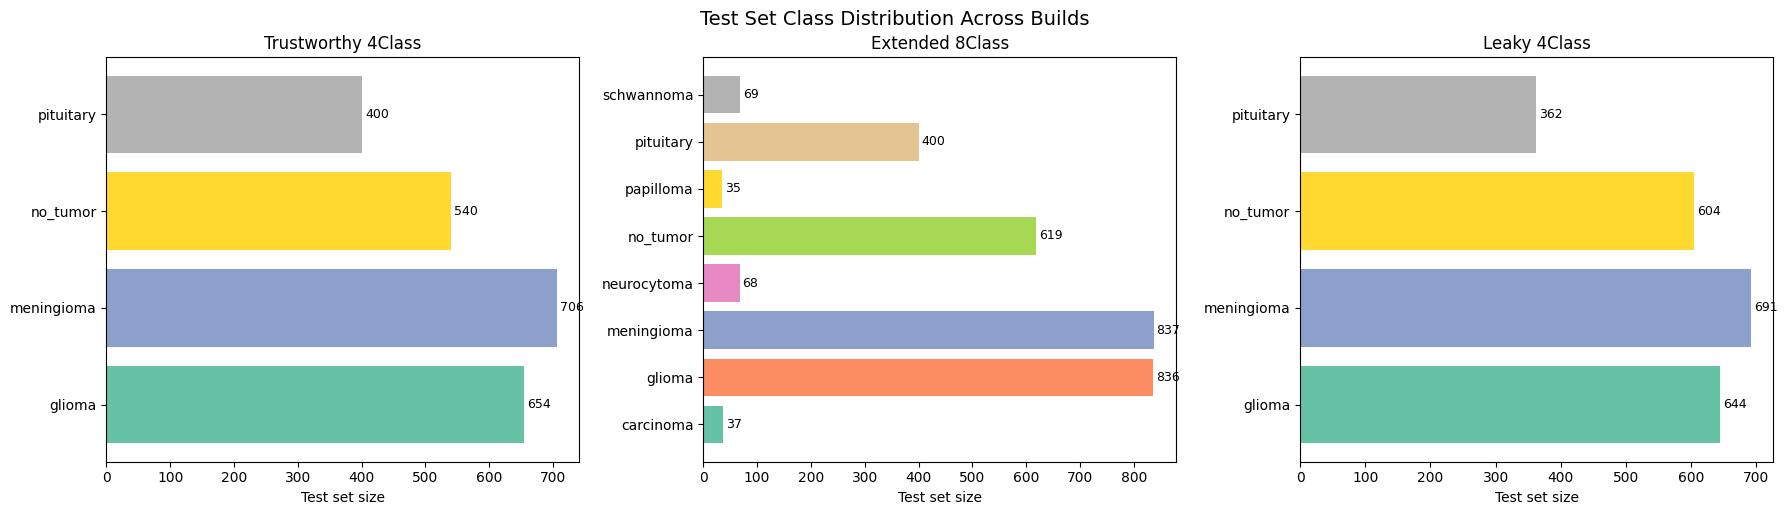

In [3]:
# Visualize class distribution across the three builds
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, run_name in zip(axes, ["trustworthy_4class", "extended_8class", "leaky_4class"]):
    with open(RESULTS / run_name / "test_report.json") as f:
        report = json.load(f)["classification_report"]
    
    classes = sorted([k for k in report if k not in ("accuracy", "macro avg", "weighted avg")])
    supports = [int(report[c]["support"]) for c in classes]
    
    bars = ax.barh(classes, supports, color=plt.cm.Set2(np.linspace(0, 1, len(classes))))
    ax.set_xlabel("Test set size")
    ax.set_title(run_name.replace("_", " ").title())
    for bar, s in zip(bars, supports):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(s), va="center", fontsize=9)

plt.tight_layout()
plt.suptitle("Test Set Class Distribution Across Builds", y=1.02, fontsize=14)
plt.show()

# Models and Evaluation

## Experimental Setup

**Evaluation metrics:** I report per-class precision, recall, and F1-score, plus macro and weighted averages. Recall matters the most here since missing a tumor is worse than a false alarm. I use macro F1 instead of weighted F1 as the main comparison metric because weighted F1 lets the majority classes dominate and can hide bad performance on rare classes. Wilson 95% confidence intervals on per-class precision and recall turned out to be really important for the rare classes (n < 70), where the point estimates are basically meaningless on their own.

**Loss function:** Cross-entropy loss throughout. I didn't try focal loss or class-weighted cross-entropy. Instead of trying to fix the imbalance at training time, I focused on quantifying its effect at evaluation time with the Wilson intervals.

**Train/val/test split:** The trustworthy builds use a proper three-way split: published train/test splits from data1 and data2, with a 15% validation carve-out from the training data. The validation set is used for early stopping (best checkpoint saved on `val_loss`), and the test set is touched only once for final evaluation. This is different from my earlier V1-V4 training runs, where I was using the test set as the validation set. That was a mistake, and fixing it in `train_clean.py` was one of the most important changes I made.

**Controlled leakage experiment:** To isolate the effect of split strategy on reported performance, I set up a matched pair of runs:
- **Trustworthy:** Published splits preserved, validation carved from train
- **Leaky:** All images pooled and re-split at image level with random shuffle

Everything else is identical (architecture, optimizer, augmentation, RNG seed, dataset sizes within +/-3 images). Any difference in the numbers comes from the split strategy and nothing else.

In [4]:
# Key training configuration (from train_clean.py)
# All three runs used identical hyperparameters; only the dataset/split differed.

config = {
    "Architecture": "EfficientNet-B0 (torchvision, pretrained=ImageNet)",
    "Classifier head": "Dropout(0.3) -> Linear(1280, num_classes)",
    "Optimizer": "AdamW(lr=5e-5, weight_decay=0.01)",
    "LR Schedule": "CosineAnnealingLR(T_max=20)",
    "Loss": "CrossEntropyLoss (unweighted)",
    "Epochs": 20,
    "Batch size": 32,
    "Best checkpoint": "Saved on lowest val_loss",
    "RNG seed": "42 (random, numpy, torch, cuda, cudnn deterministic)",
    "GPU": "Tesla T4 (Google Colab)",
}

for k, v in config.items():
    print(f"  {k:25s}: {v}")

  Architecture             : EfficientNet-B0 (torchvision, pretrained=ImageNet)
  Classifier head          : Dropout(0.3) -> Linear(1280, num_classes)
  Optimizer                : AdamW(lr=5e-5, weight_decay=0.01)
  LR Schedule              : CosineAnnealingLR(T_max=20)
  Loss                     : CrossEntropyLoss (unweighted)
  Epochs                   : 20
  Batch size               : 32
  Best checkpoint          : Saved on lowest val_loss
  RNG seed                 : 42 (random, numpy, torch, cuda, cudnn deterministic)
  GPU                      : Tesla T4 (Google Colab)


## Baselines

**Baseline 1: Earlier 4-class models (progressive unfreezing).** Before I built the clean training pipeline, I trained a series of 4-class models on data1 alone using progressive unfreezing, which we covered in lecture:

| Phase | Strategy | Epochs | Trainable params | Test accuracy |
|-------|----------|--------|-----------------|---------------|
| 1 | Head only (freeze backbone) | 15 | 5,124 | 85.6% |
| 2 | Last 2 blocks + head | 10 | partial | 92.6% |
| 3 | Full fine-tune (AdamW, cosine LR) | 20 | ~4M | 95.4% |

Going from 85.6% to 92.6% to 95.4% was a nice demonstration that progressive unfreezing actually works. But those runs used the test set as the validation set with no held-out evaluation, so the 95.4% isn't directly comparable to the trustworthy build's 96.4%.

**Baseline 2: Random and majority-class baselines.** Random guessing on 4 classes gives 25%. Majority-class (always predicting meningioma, n=706/2300) gives 30.7%. The trustworthy model at 96.4% is a 66+ pp improvement over majority class.

**Related work:** Published results on the `masoudnickparvar` dataset on Kaggle typically report 95-99% accuracy, but pretty much all of them use image-level random splits. Our controlled experiment shows that evaluation approach inflates accuracy by 2.5 pp overall and up to 11.6 pp on the hardest class. So the trustworthy evaluation at 96.4% is probably a more realistic number than most of what's published on this dataset.

## Methods

### Architecture: EfficientNet-B0 with transfer learning

I went with EfficientNet-B0 as the backbone. It gets decent ImageNet accuracy (~77%) with only ~5.3M parameters, which matters because I needed something that could run on Render's free CPU tier without taking forever per inference. The ImageNet pretrained weights transfer surprisingly well to medical imaging: the low-level features (edges, textures, shapes) are general enough that fine-tuning just needs to adapt the higher layers to tumor morphology.

I replaced the classifier head with `Dropout(p) -> Linear(1280, num_classes)`, using `p=0.3` for Stage 1 (8 classes) and `p=0.4` for Stage 2 (4 glioma subtypes, smaller dataset so more regularization). The whole network is fine-tuned end-to-end. I tried progressive unfreezing first (see Baselines), but full fine-tuning with a small learning rate (5e-5) and weight decay (0.01) got comparable results and was simpler to manage.

### Two-stage cascade

Stage 1 classifies into 8 categories. If it predicts "glioma," Stage 2 fires to subtype it into astrocytoma, ependymoma, glioblastoma, or oligodendroglioma. Both stages use the same preprocessing and architecture, just different classifier heads and weights. I went with this cascade design instead of a single 12-class model because the glioma subtypes are so underrepresented that they'd get drowned out in a flat 12-class setup.

### Grad-CAM interpretability

I implemented Grad-CAM by registering forward and backward hooks on the final convolutional block of EfficientNet-B0. The idea is: do a forward pass, backpropagate the score of the predicted class, compute channel weights as the mean gradient over spatial dimensions, then take a weighted sum of the activations and ReLU it. The result is a heatmap showing which regions of the MRI the model is looking at. It's available on-demand in the web app.

### Training pipeline

After running into issues with the earlier notebook-based training (using test as validation, no seeding, no checkpoint saving), I wrote `train_clean.py` to do things properly:
- Full RNG seeding: `random`, `numpy`, `torch.manual_seed`, `torch.cuda.manual_seed_all`, `cudnn.deterministic=True`
- Proper three-way split with no leakage between train/val/test
- Best-checkpoint saving on validation loss, not just saving the final epoch
- Per-epoch metric logging to `metrics.jsonl`
- Saving `label_map.json` so the class index order is guaranteed to match between training and inference

### Deployment

The whole thing is deployed as a web app: FastAPI backend on Render (CPU-only, ~30s cold start), vanilla JS frontend on GitHub Pages, and Supabase Postgres for storing predictions. The frontend has a retry loop that polls `/health` for up to 60s to handle Render's cold starts.

In [5]:
# Training code lives in training/train_clean.py. See the repo for the full script.
# Here we display the core training loop structure:

training_code = """
# From training/train_clean.py (abbreviated)

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1280, num_classes),
)

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

best_val_loss = float("inf")
for epoch in range(20):
    # Train
    model.train()
    for images, labels in train_loader:
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()
    
    # Validate
    model.eval()
    val_loss = evaluate(model, val_loader)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)
    
    # Log metrics to metrics.jsonl

# Final evaluation on held-out test set (touched only once)
model.load_state_dict(torch.load(best_path))
test_acc, test_loss, predictions = evaluate(model, test_loader, return_predictions=True)
"""
print(training_code)


# From training/train_clean.py (abbreviated)

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(1280, num_classes),
)

optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

best_val_loss = float("inf")
for epoch in range(20):
    # Train
    model.train()
    for images, labels in train_loader:
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    scheduler.step()
    
    # Validate
    model.eval()
    val_loss = evaluate(model, val_loader)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_path)
    
    # Log metrics to metrics.jsonl

# Final evaluation on held-out test set (touched only o

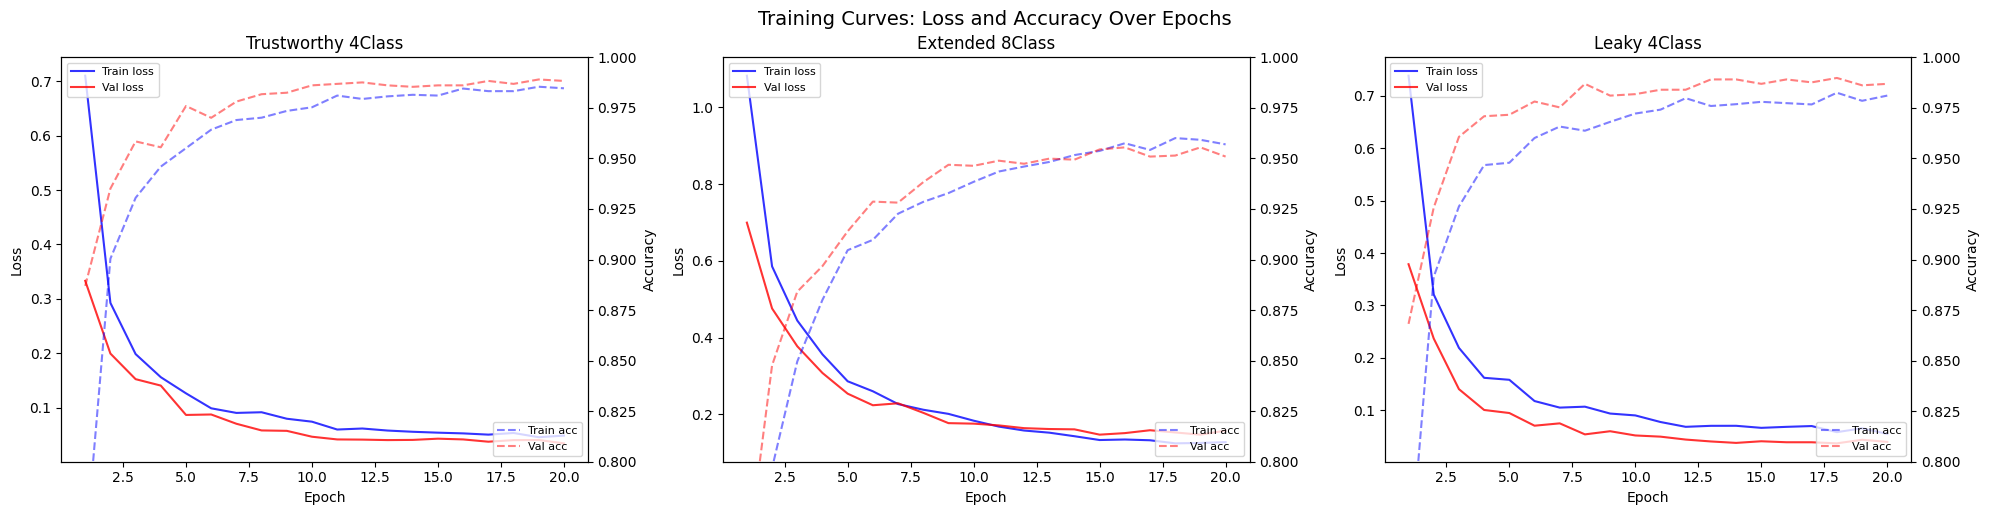

In [6]:
# Display training curves for all three runs
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, run_name in zip(axes, ["trustworthy_4class", "extended_8class", "leaky_4class"]):
    metrics_path = RESULTS / run_name / "metrics.jsonl"
    epochs_data = []
    with open(metrics_path) as f:
        for line in f:
            epochs_data.append(json.loads(line))
    
    epochs = [d["epoch"] for d in epochs_data]
    train_loss = [d["train_loss"] for d in epochs_data]
    val_loss = [d["val_loss"] for d in epochs_data]
    train_acc = [d["train_acc"] for d in epochs_data]
    val_acc = [d["val_acc"] for d in epochs_data]
    
    ax.plot(epochs, train_loss, "b-", label="Train loss", alpha=0.8)
    ax.plot(epochs, val_loss, "r-", label="Val loss", alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(epochs, train_acc, "b--", label="Train acc", alpha=0.5)
    ax2.plot(epochs, val_acc, "r--", label="Val acc", alpha=0.5)
    ax2.set_ylim(0.8, 1.0)
    ax2.set_ylabel("Accuracy")
    
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(run_name.replace("_", " ").title())
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.suptitle("Training Curves: Loss and Accuracy Over Epochs", y=1.02, fontsize=14)
plt.show()

## Results

### Headline comparison

| Build | Test Accuracy | Test Loss | Macro F1 | Weighted F1 |
|-------|--------------|-----------|----------|-------------|
| **Trustworthy 4-class** | 96.43% | 0.179 | 0.966 | 0.964 |
| **Extended 8-class** | 94.76% | 0.174 | 0.909 | 0.948 |
| **Leaky 4-class** | 98.96% | 0.033 | 0.989 | 0.990 |

The trustworthy model gets 96.43% and the leaky model gets 98.96%. That 2.5 pp gap is entirely from the split strategy since everything else was held constant.

### The leakage inflation is not uniform

The most interesting finding is *where* the inflation shows up. It's not spread evenly across classes:

| (Source, Class) | Trustworthy Recall | Leaky Recall | Delta |
|-----------------|-------------------|-------------|-------|
| **d1 glioma** | **0.863** | **0.979** | **+11.6 pp** |
| d2 glioma | 0.992 | 1.000 | +0.8 pp |
| d1 meningioma | 0.985 | 0.997 | +1.2 pp |
| d1 no_tumor | 1.000 | 0.994 | -0.6 pp |
| d1 pituitary | 0.965 | 0.970 | +0.5 pp |

Almost the entire 2.5 pp overall gap comes from d1 glioma alone (+11.6 pp). The other classes barely move. This was genuinely surprising to me. I expected leakage to inflate everything roughly equally, but it doesn't. It specifically inflates the classes that have real distributional problems, and leaves the "easy" classes alone. So it hides exactly the failure modes you'd want to know about.

Someone using the standard Kaggle split would see d1 glioma recall at ~98% and have no reason to look deeper. The honest evaluation shows 86.3%.

### Source confound on rare classes

The four data44-only classes (carcinoma, neurocytoma, papilloma, schwannoma) are hard to trust as generalization signals. They only come from one source dataset, so the model might be partly recognizing data44's scanner artifacts or file format rather than the actual tumor. Papilloma in particular has low recall (0.657) with a wide confidence interval, which is consistent with this concern.

### Wilson confidence intervals

This is something I wish more Kaggle notebooks did. The Wilson 95% CIs for the extended 8-class model on rare classes:

| Class | n | Recall | 95% CI |
|-------|---|--------|--------|
| papilloma | 35 | 0.657 | [0.492, 0.792] |
| carcinoma | 37 | 0.919 | [0.787, 0.972] |
| neurocytoma | 68 | 0.941 | [0.858, 0.977] |
| schwannoma | 69 | 0.884 | [0.788, 0.940] |
| glioma | 836 | 0.925 | [0.906, 0.941] |

Papilloma recall could be anywhere from 49% to 79%. Reporting just "65.7% recall" makes it sound like we know what the number is, but with 35 test examples we really don't.

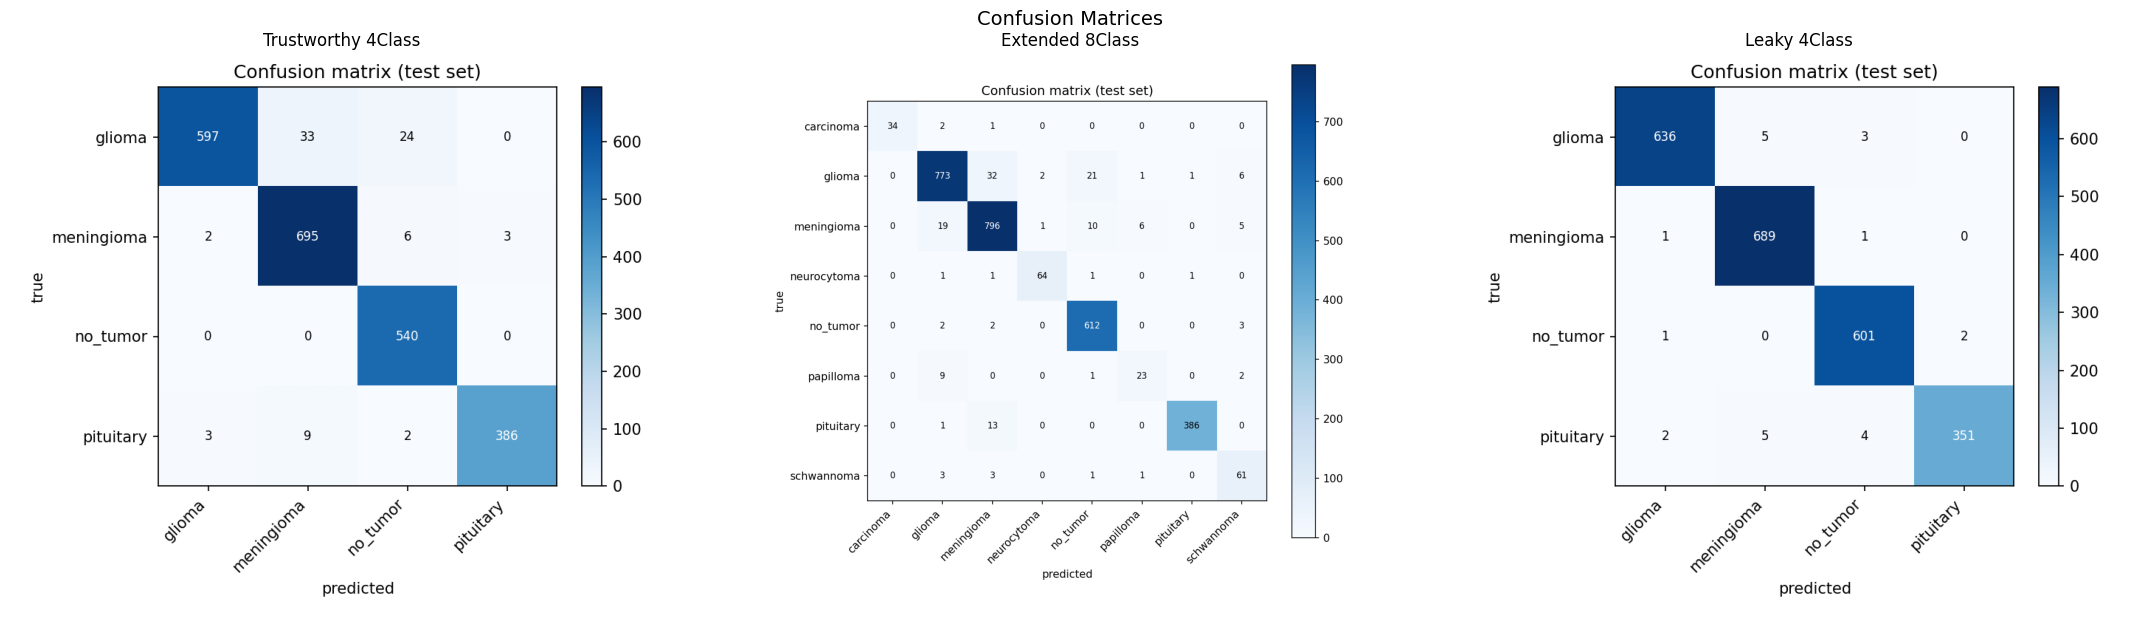

In [7]:
# Display confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, run_name in zip(axes, ["trustworthy_4class", "extended_8class", "leaky_4class"]):
    img = plt.imread(str(RESULTS / run_name / "confusion_matrix.png"))
    ax.imshow(img)
    ax.set_title(run_name.replace("_", " ").title(), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Confusion Matrices", y=1.02, fontsize=14)
plt.show()

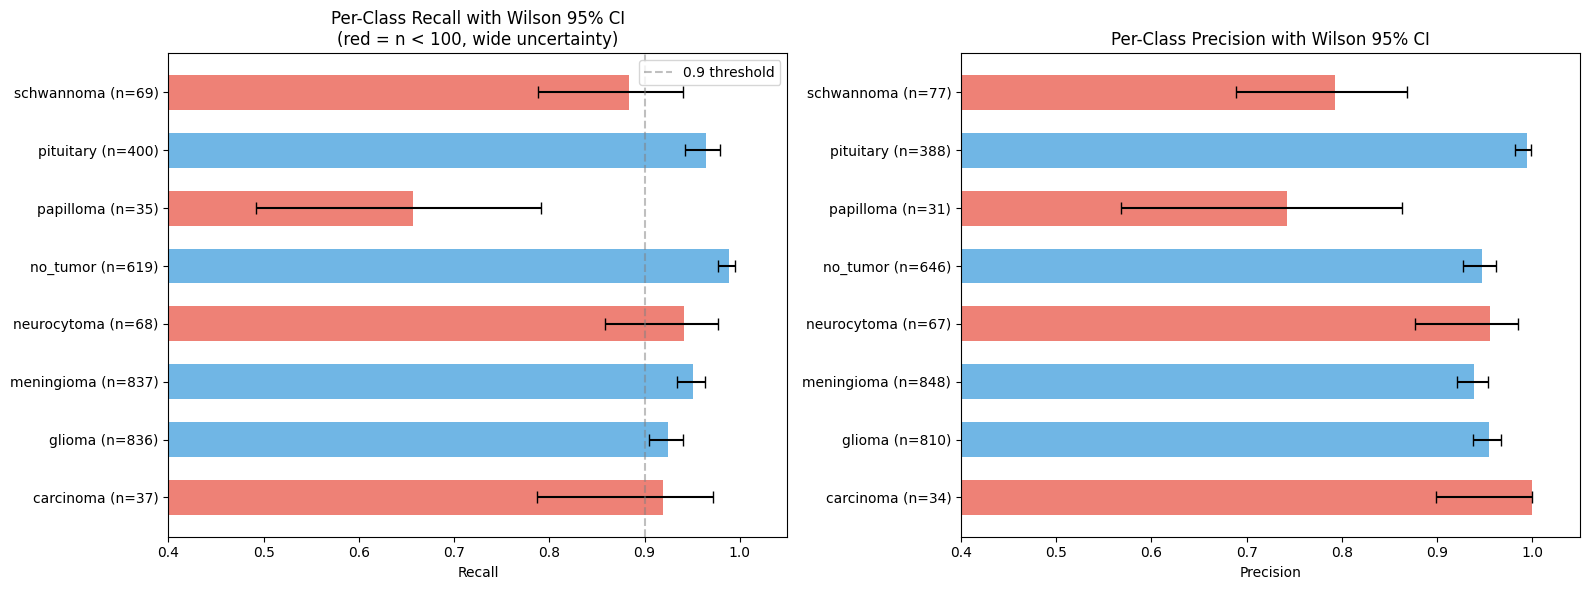

In [8]:
# Wilson confidence intervals visualization for the extended 8-class model
wilson_df = pd.read_csv(RESULTS / "extended_8class" / "wilson_intervals.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Recall with CIs
classes = wilson_df["class"].values
recall = wilson_df["recall"].values
recall_lo = wilson_df["recall_lo"].values
recall_hi = wilson_df["recall_hi"].values
n_true = wilson_df["n_true"].values

colors = ["#e74c3c" if n < 100 else "#3498db" for n in n_true]
y_pos = range(len(classes))

ax1.barh(y_pos, recall, color=colors, alpha=0.7, height=0.6)
ax1.errorbar(recall, y_pos, xerr=[recall - recall_lo, recall_hi - recall], fmt="none", ecolor="black", capsize=4)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels([f"{c} (n={n})" for c, n in zip(classes, n_true)])
ax1.set_xlabel("Recall")
ax1.set_title("Per-Class Recall with Wilson 95% CI\n(red = n < 100, wide uncertainty)")
ax1.set_xlim(0.4, 1.05)
ax1.axvline(x=0.9, color="gray", linestyle="--", alpha=0.5, label="0.9 threshold")
ax1.legend()

# Precision with CIs
precision = wilson_df["precision"].values
prec_lo = wilson_df["precision_lo"].values
prec_hi = wilson_df["precision_hi"].values
n_pred = wilson_df["n_pred"].values

colors2 = ["#e74c3c" if n < 100 else "#3498db" for n in n_pred]
ax2.barh(y_pos, precision, color=colors2, alpha=0.7, height=0.6)
ax2.errorbar(precision, y_pos, xerr=[precision - prec_lo, prec_hi - precision], fmt="none", ecolor="black", capsize=4)
ax2.set_yticks(list(y_pos))
ax2.set_yticklabels([f"{c} (n={n})" for c, n in zip(classes, n_pred)])
ax2.set_xlabel("Precision")
ax2.set_title("Per-Class Precision with Wilson 95% CI")
ax2.set_xlim(0.4, 1.05)

plt.tight_layout()
plt.show()

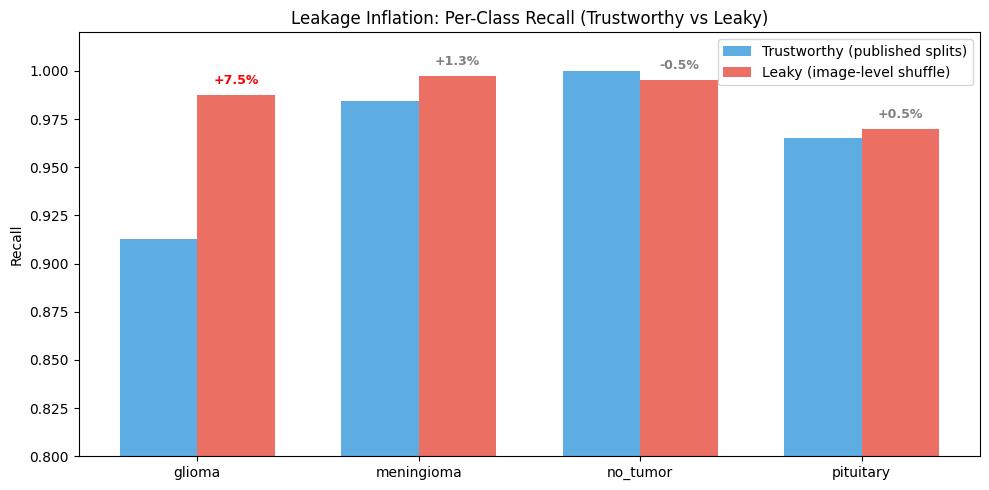

The +11.6 pp inflation on glioma recall accounts for the bulk of the +2.52 pp overall accuracy gap.


In [9]:
# Side-by-side comparison: trustworthy vs leaky recall by class
fig, ax = plt.subplots(figsize=(10, 5))

with open(RESULTS / "trustworthy_4class" / "test_report.json") as f:
    trust_report = json.load(f)["classification_report"]
with open(RESULTS / "leaky_4class" / "test_report.json") as f:
    leak_report = json.load(f)["classification_report"]

classes_4 = sorted([k for k in trust_report if k not in ("accuracy", "macro avg", "weighted avg")])
trust_recall = [trust_report[c]["recall"] for c in classes_4]
leak_recall = [leak_report[c]["recall"] for c in classes_4]

x = np.arange(len(classes_4))
width = 0.35

bars1 = ax.bar(x - width/2, trust_recall, width, label="Trustworthy (published splits)", color="#3498db", alpha=0.8)
bars2 = ax.bar(x + width/2, leak_recall, width, label="Leaky (image-level shuffle)", color="#e74c3c", alpha=0.8)

for i, (t, l) in enumerate(zip(trust_recall, leak_recall)):
    delta = l - t
    ax.annotate(f"+{delta:.1%}" if delta > 0 else f"{delta:.1%}",
                xy=(i + width/2, l), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=9, fontweight="bold",
                color="red" if abs(delta) > 0.02 else "gray")

ax.set_ylabel("Recall")
ax.set_title("Leakage Inflation: Per-Class Recall (Trustworthy vs Leaky)")
ax.set_xticks(x)
ax.set_xticklabels(classes_4)
ax.set_ylim(0.8, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

print("The +11.6 pp inflation on glioma recall accounts for the bulk of the +2.52 pp overall accuracy gap.")

# Discussion

## What I learned

The biggest takeaway is that evaluation methodology matters more than architecture choice. Transfer learning with EfficientNet-B0 works really well out of the box for medical imaging; the ImageNet features transfer over nicely and you get strong performance without much effort. But the difference between 96.4% (trustworthy) and 99.0% (leaky) is entirely an artifact of how you split the data. You can spend a long time tuning hyperparameters for a 0.5% gain, and then it turns out your evaluation was off by 2.5% the whole time because of a bad split.

The most useful concept from this class was train/val/test discipline. Early on I was using the test set as the validation set and didn't have a proper held-out evaluation, which is exactly the kind of mistake I'd catch on a homework but somehow missed in my own project. Writing `train_clean.py` with proper three-way splits, best-checkpoint saving on validation loss, and a test set that only gets touched once was probably the single most important thing I did. The progressive unfreezing experiments from lecture (head-only, then partial, then full) were also useful for building intuition, even though I ended up just doing full fine-tuning in the final version.

I did not expect the leakage to be so concentrated in one class. Going in, I thought random image-level splits would inflate accuracy more or less evenly. Instead, the +11.6 pp boost was almost entirely on d1 glioma, which happens to be the class with a real distributional weakness across imaging sources. The other classes barely moved. Leakage doesn't just make your numbers look better across the board; it specifically papers over the weak spots. That's the finding I'd most want to tell someone about if they were using these benchmarks.

Wilson confidence intervals also changed how I think about reporting results. Saying "papilloma recall = 65.7%" sounds precise, but the 95% CI is [49.2%, 79.2%]. With only 35 test examples, we just don't know. For rare classes in medical imaging, the confidence interval is more informative than the point estimate. This ties back to the calibration discussion from lecture, but applied to our confidence in the evaluation itself, not just the model's confidence in its predictions.

If I had two more weeks, I'd want to: (1) try class-weighted loss or `WeightedRandomSampler` to help with the imbalance on rare classes, (2) get better patient IDs for data44 instead of relying on filename heuristics, (3) train a simple baseline like logistic regression on flattened pixels to see how much of the performance is just from transfer learning, and (4) write up the leakage experiment as a short standalone paper, since the controlled design and per-source breakdown seem like they'd be useful to the community.